In [19]:
import pandas as pd
from matplotlib import pyplot as plt

In [20]:
df = pd.read_csv("nasdaq100.csv", sep=";")  # separating by ";"
df

,Date,Starting (USD),Ending (USD)
0,01.01.24,16800,16500
1,01.12.23,15900,16100
2,01.11.23,15800,15300
3,01.10.23,16100,16200
4,01.09.23,16300,15700
5,01.08.23,16800,16400
6,01.07.23,15900,16200
7,01.06.23,15800,15500
8,01.05.23,16150,16100
9,01.04.23,16300,15800


In [21]:
df.isnull().sum()  # isnull() shows the whole df with true false value. .sum() shows every cols null value count

Date              0
Starting (USD)    0
Ending (USD)      0
dtype: int64

In [22]:
# df = df.drop('Date', axis=1)
df = df.drop(columns=["Date"])  # deletes date column
df

,Starting (USD),Ending (USD)
0,16800,16500
1,15900,16100
2,15800,15300
3,16100,16200
4,16300,15700
5,16800,16400
6,15900,16200
7,15800,15500
8,16150,16100
9,16300,15800


In [26]:
x = df[["Starting (USD)"]]
x

,Starting (USD)
0,16800
1,15900
2,15800
3,16100
4,16300
5,16800
6,15900
7,15800
8,16150
9,16300


In [28]:
y = df[["Ending (USD)"]]
y

,Ending (USD)
0,16500
1,16100
2,15300
3,16200
4,15700
5,16400
6,16200
7,15500
8,16100
9,15800


Text(0.5, 1.0, 'NASDAQ100 Stock Prize')

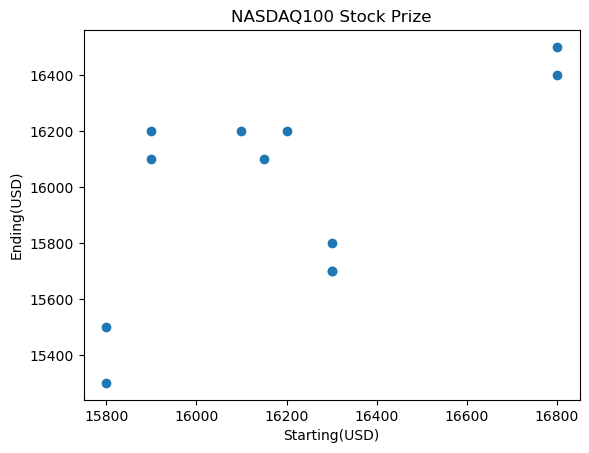

In [29]:
plt.scatter(x, y)
plt.xlabel("Starting(USD)")
plt.ylabel("Ending(USD)")
plt.title("NASDAQ100 Stock Prize")

In [31]:
from sklearn.linear_model import LinearRegression
lr = LinearRegression() # just a variable to work easily
lr.fit(x, y)  # training the model with data

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [32]:
df["Predicted_y"] = lr.predict(x)
df

,Starting (USD),Ending (USD),Predicted_y
0,16800,16500,16369.268856
1,15900,16100,15781.944215
2,15800,15300,15716.685922
3,16100,16200,15912.460802
4,16300,15700,16042.977389
5,16800,16400,16369.268856
6,15900,16200,15781.944215
7,15800,15500,15716.685922
8,16150,16100,15945.089949
9,16300,15800,16042.977389


Text(0.5, 1.0, 'NASDAQ100 Stock Price')

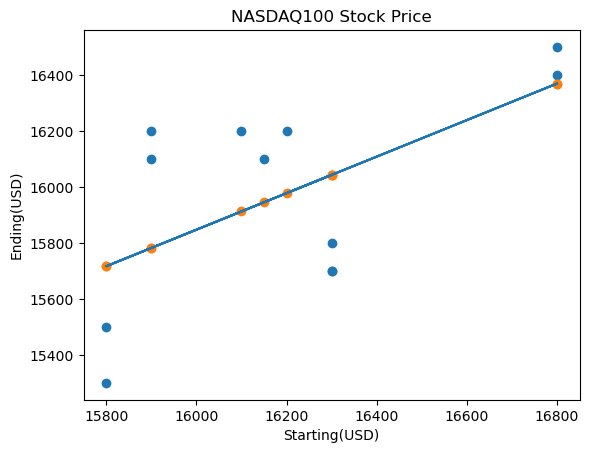

In [36]:
plt.scatter(x, y) # shows the dots for real data
plt.scatter(x, df["Predicted_y"]) # shows the dots for predicted data
plt.plot(x, df["Predicted_y"])  # shows line for predicted data
plt.xlabel("Starting(USD)")
plt.ylabel("Ending(USD)")
plt.title("NASDAQ100 Stock Price")

In [39]:
pred_val = lr.predict([[16600]])  # predicts for only one value
pred_val

C:\Users\tanvi\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([[16238.75226935]])

# Loss and Cost Function

In [41]:
df["Loss"] = df["Ending (USD)"] - df["Predicted_y"]
df.head()

,Starting (USD),Ending (USD),Predicted_y,Loss
0,16800,16500,16369.268856,130.731144
1,15900,16100,15781.944215,318.055785
2,15800,15300,15716.685922,-416.685922
3,16100,16200,15912.460802,287.539198
4,16300,15700,16042.977389,-342.977389


In [42]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
mse = mean_squared_error(df["Ending (USD)"], df["Predicted_y"])
mse

80411.23397700385

In [43]:
mae = mean_absolute_error(df['Ending (USD)'], df['Predicted_y'])
mae

260.3840017604666